# Logistic Regression: Binary Classification

## Logistic Regression

## What is Logistic Regression?

**Logistic Regression** is a Machine Learning algorithm used for **classification**.

It is mainly used for **binary classification**, where there are two classes.

Example:

- `0` → No car
- `1` → Owns car

Logistic Regression predicts the **probability** of each class and then uses a **threshold** to make the final prediction.

---

## Sigmoid Function

The **Sigmoid function** converts the model's output into a value between **0 and 1**.

This value can be treated as a **probability**.

### Formula

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Where:

- `z` = output from the model
- `e` = Euler's number ≈ `2.71828`

### Simple Example

Suppose the model gives:

$$
z = 2
$$

After applying the Sigmoid function:

$$
\sigma(2) \approx 0.88
$$

So:

**Probability = 88%**

---

## Why do we use Sigmoid?

The model's raw output can be any number, such as:

`-5, -2, 0, 2, 5`

The Sigmoid function converts these values into probabilities between `0` and `1`.

**Raw output → Sigmoid → Probability**

Example:

`2 → Sigmoid → 0.88 → 88%`

---

## model.predict_proba()

`model.predict_proba()` gives the **probability of each class**.

Example:

`model.predict_proba(X_test)`

Suppose the output is:

`[[0.30, 0.70]]`

This means:

- **Class 0 → 30%**
- **Class 1 → 70%**

The probabilities add up to **100%**.

## Threshold

### Code

    # Get probability of class 1
    probability = model.predict_proba(x_test)[:, 1]

    # Set threshold
    threshold = 0.5

    # Convert probability into 0 or 1
    y_pred = (probability >= threshold).astype(int)

    print(y_pred)

### Example

Suppose:

    probability = [0.30, 0.70, 0.45, 0.80]

With **threshold = 0.5**:

    0.30 < 0.5  → 0
    0.70 ≥ 0.5  → 1
    0.45 < 0.5  → 0
    0.80 ≥ 0.5  → 1

### Result

    [0, 1, 0, 1]

### How it works

    Probability
         ↓
    Compare with threshold
         ↓
    Probability ≥ 0.5 → 1
    Probability < 0.5 → 0

### Important

`.astype(int)` converts:

    True  → 1
    False → 0

It does **not** convert `0.70` directly to `0`.

---

## Understanding predict_proba()

**Probability**

↓

**Class 0        Class 1**

**30%              70%**

↓                     ↓

**No car        Owns car**

Since Class 1 has the higher probability:

**Prediction = 1**

---

## Threshold

A **threshold** is the value used to decide the final class.

The default threshold is usually:

**0.5**

### Example 1

Class 1 probability = **70%**

Since:

$$
0.70 > 0.50
$$

Prediction:

**Class 1**

---

### Example 2

Class 1 probability = **30%**

Since:

$$
0.30 < 0.50
$$

Prediction:

**Class 0**

---

## Simple Rule

**Probability ≥ 0.5 → Class 1**

**Probability < 0.5 → Class 0**

---

## Complete Example

Suppose we want to predict whether a person owns a car.

**Class 0 → No car**

**Class 1 → Owns car**

The model gives:

**Class 0 → 30%**

**Class 1 → 70% ← higher**

↓

**Prediction = 1**

### Probability

| Class 0 | Class 1 |
|----------|----------|
| 30% | 70% |
| No car | Owns car |

Therefore:

**Final Prediction = Class 1**

**Meaning = Person owns a car**

---

## Easy Way to Remember

**Logistic Regression** → Used for classification.

**Sigmoid** → Converts model output into probability between `0` and `1`.

**predict_proba()** → Shows probability for each class.

**Threshold** → Decides the final class.

**Default threshold = 0.5**

### In one line

**Logistic Regression → Sigmoid → Probability → Threshold → Final Prediction**

In [1]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\car_ownership.csv")
df.head()

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


In [2]:
from sklearn.model_selection import train_test_split

x=df[["monthly_salary"]]
y=df["owns_car"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [3]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
y_test.to_list()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [5]:
model.predict(x_test)

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [6]:
model.score(x_test,y_test)

0.8888888888888888

In [7]:
8/9

0.8888888888888888

In [8]:
model.predict_proba(x_test)

array([[0.04530932, 0.95469068],
       [0.80955349, 0.19044651],
       [0.05158003, 0.94841997],
       [0.86480041, 0.13519959],
       [0.91687254, 0.08312746],
       [0.82967465, 0.17032535],
       [0.87995016, 0.12004984],
       [0.07564619, 0.92435381],
       [0.84806892, 0.15193108]])

# Model Evaluation: Accuracy, Precision and Recall

In [9]:
y_test.to_list()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [10]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

## f1_score
### F1 Score Formula

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

### Precision Formula

$$
Precision = \frac{TP}{TP + FP}
$$

Where:

- **TP** = True Positive
- **FP** = False Positive

### Recall Formula

$$
Recall = \frac{TP}{TP + FN}
$$

Where:

- **TP** = True Positive
- **FN** = False Negative

---
### TP, TN, FP, FN

**1 = Positive**  
**0 = Negative**

| Actual | Predicted | Result |
|--------|-----------|--------|
| 1 | 1 | TP |
| 0 | 0 | TN |
| 0 | 1 | FP |
| 1 | 0 | FN |

In [11]:
print(y_test.to_list())
print(y_pred.tolist())

model.score(x_test,y_test)

[1, 0, 1, 0, 0, 0, 1, 1, 0]
[1, 0, 1, 0, 0, 0, 0, 1, 0]


0.8888888888888888

In [12]:
from sklearn.metrics import classification_report

report=classification_report(y_test,model.predict(x_test))
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



In [13]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(precision)

1.0


# Model Evaluation: F1 Score, Confusion Matrix

## F1 Score Formula

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

In [17]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,model.predict(x_test))
print(round(f1,2))

0.86


## conusion matrix

A **Confusion Matrix** is used to check how well a classification model is predicting the classes.

### Our Confusion Matrix

| True \ Predicted | No Car (0) | Owns Car (1) |
|---|---:|---:|
| **No Car (0)** | **5** | **0** |
| **Owns Car (1)** | **1** | **3** |

### How to Read It

- **Rows = True Labels** → What actually happened
- **Columns = Predicted Labels** → What the model predicted

### 1. True Negative (TN) = 5

Actual: **No Car**  
Predicted: **No Car**

✅ The model correctly predicted 5 people who do not own a car.

### 2. False Positive (FP) = 0

Actual: **No Car**  
Predicted: **Owns Car**

There are **0** such cases.

### 3. False Negative (FN) = 1

Actual: **Owns Car**  
Predicted: **No Car**

❌ The model incorrectly predicted 1 car owner as someone who does not own a car.

### 4. True Positive (TP) = 3

Actual: **Owns Car**  
Predicted: **Owns Car**

✅ The model correctly predicted 3 car owners.

### Summary

- **TN = 5**
- **FP = 0**
- **FN = 1**
- **TP = 3**

### Accuracy

Correct predictions:

$$
5 + 3 = 8
$$

Total predictions:

$$
5 + 0 + 1 + 3 = 9
$$

Therefore:

$$
Accuracy = \frac{8}{9} = 88.89\%
$$

So, the model correctly classified **8 out of 9** people.

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,model.predict(x_test))
cm

array([[5, 0],
       [1, 3]])

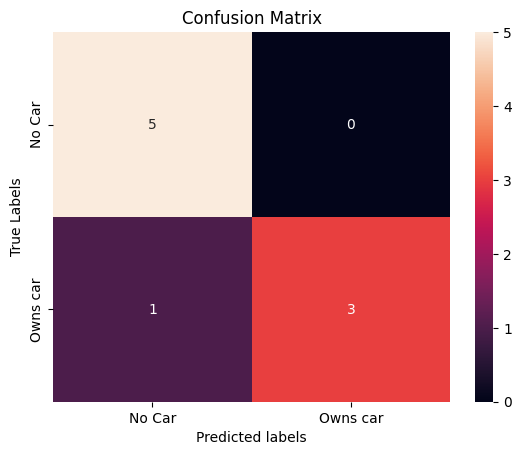

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
classes=["No Car","Owns car"]
sns.heatmap(cm,annot=True,xticklabels=classes,yticklabels=classes)

plt.xlabel("Predicted labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()